# Financial Phrasebank — EDA
Veriye ilk bakış: dağılım, metin uzunluğu, class imbalance.

In [1]:
import sys
sys.path.append('..')  # src klasörüne erişim için

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
COLORS = {'negative': '#e74c3c', 'neutral': '#95a5a6', 'positive': '#2ecc71'}

df = pd.read_csv('../data/financial_phrasebank.csv')
print(f'Toplam örnek: {len(df)}')
df.head(3)

Toplam örnek: 2264


,sentence,label,label_str
0,"According to Gran , the company has no plans t...",1,neutral
1,"For the last quarter of 2010 , Componenta 's n...",2,positive
2,"In the third quarter of 2010 , net sales incre...",2,positive


## 1. Label Dağılımı

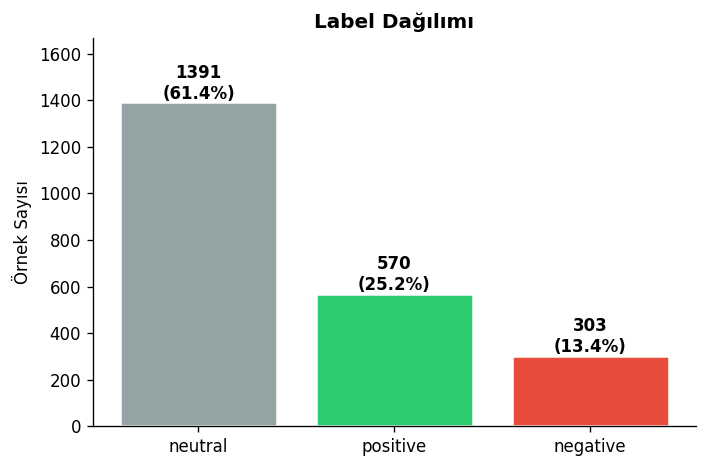


Imbalance ratio (majority/minority):
  neutral     1391  ratio: 1.00x
  positive     570  ratio: 2.44x
  negative     303  ratio: 4.59x


In [2]:
counts = df['label_str'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values,
              color=[COLORS[l] for l in counts.index], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{val}\n({pct:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Label Dağılımı', fontweight='bold')
ax.set_ylabel('Örnek Sayısı')
ax.set_ylim(0, counts.max() * 1.2)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nImbalance ratio (majority/minority):')
for label, count in counts.items():
    print(f'  {label:<10} {count:>5}  ratio: {counts.max()/count:.2f}x')

## 2. Metin Uzunluğu Analizi

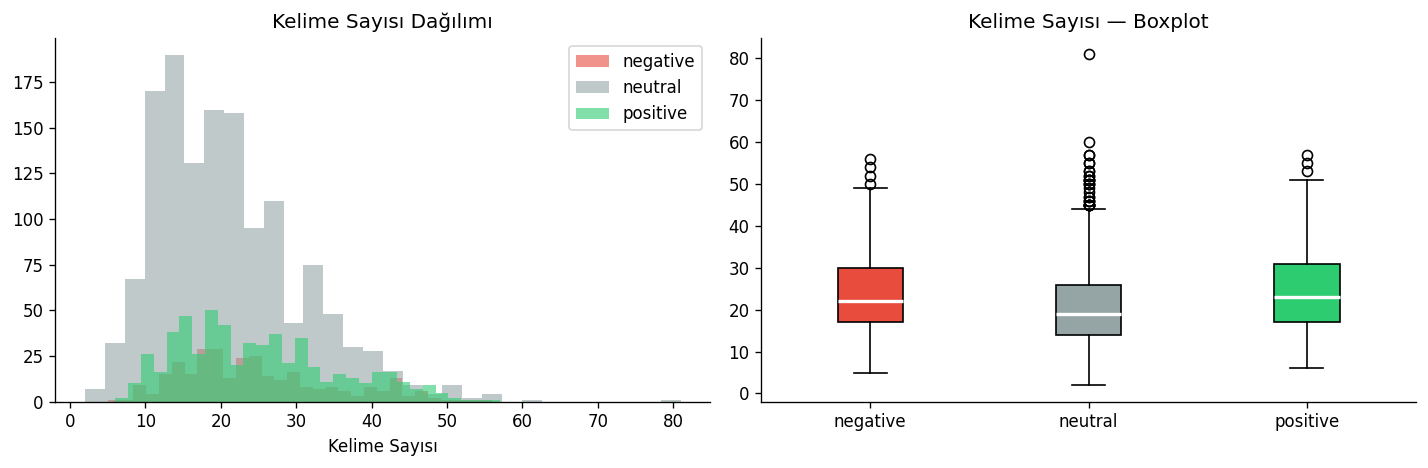

           mean  min   50%   max
label_str                       
negative   24.8  5.0  22.0  56.0
neutral    20.9  2.0  19.0  81.0
positive   24.9  6.0  23.0  57.0

512 token'ı aşan: 0 cümle


In [3]:
df['word_count']   = df['sentence'].str.split().str.len()
df['char_count']   = df['sentence'].str.len()
df['token_approx'] = (df['char_count'] / 4).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
for label in ['negative', 'neutral', 'positive']:
    axes[0].hist(df[df['label_str']==label]['word_count'],
                 bins=30, alpha=0.6, color=COLORS[label], label=label)
axes[0].set_title('Kelime Sayısı Dağılımı')
axes[0].set_xlabel('Kelime Sayısı')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Boxplot
data_bp = [df[df['label_str']==l]['word_count'].values for l in ['negative','neutral','positive']]
bp = axes[1].boxplot(data_bp, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, label in zip(bp['boxes'], ['negative','neutral','positive']):
    patch.set_facecolor(COLORS[label])
axes[1].set_xticklabels(['negative','neutral','positive'])
axes[1].set_title('Kelime Sayısı — Boxplot')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print(df.groupby('label_str')['word_count'].describe()[['mean','min','50%','max']].round(1))
print(f"\n512 token'ı aşan: {(df['token_approx'] > 512).sum()} cümle")

## 3. Örnek Cümleler

In [4]:
for label in ['negative', 'neutral', 'positive']:
    print(f'\n[{label.upper()}]')
    for s in df[df['label_str']==label]['sentence'].sample(2, random_state=42):
        print(f'  • {s[:130]}{"..." if len(s)>130 else ""}')


[NEGATIVE]
  • Earnings per share ( EPS ) in 2005 decreased to EUR1 .87 from EUR1 .89 in 2003 .
  • Alma Media 's operating profit amounted to EUR 11.9 mn , down from EUR 15.0 mn a year earlier .

[NEUTRAL]
  • There have not been previous share subscriptions with 2004 stock options .
  • The event can be followed on-line via Orion 's Finnish homepage at www.orion.fi as well as via the Kauppalehti Live web service at...

[POSITIVE]
  • These measures are expected to produce annual cost savings of EUR 1.5 million starting in 2007 .
  • The last quarter was the best quarter of 2009 in net sales , and the operating margin rose to 12.2 % .
